In [33]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, GRU

In [5]:
from tensorflow.keras.datasets import imdb

In [15]:
# load the imdb datasets
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=10000)

In [16]:
# padded _sequence to have the same length
X_train=pad_sequences(X_train,maxlen=100)
X_test =pad_sequences(X_test,maxlen=100)

In [21]:
#DEFINE THE RNN MODEL
model = Sequential([
    Embedding(10000,32,input_length=100),  # embedding layer to convert words into vectors
    SimpleRNN(5,return_sequences=True),    # another rnn layer of 5 units
    SimpleRNN(5),    # simple RNN layer with 5 units
    Dense(1,activation='sigmoid')             # output layer for binary classification
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
# compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [23]:
history =model.fit(X_train,y_train,epochs=5,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - accuracy: 0.5753 - loss: 0.6622 - val_accuracy: 0.7527 - val_loss: 0.5267
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 53ms/step - accuracy: 0.8205 - loss: 0.4204 - val_accuracy: 0.7740 - val_loss: 0.4894
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.8855 - loss: 0.2984 - val_accuracy: 0.7814 - val_loss: 0.5397
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9194 - loss: 0.2239 - val_accuracy: 0.7846 - val_loss: 0.5476
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9423 - loss: 0.1675 - val_accuracy: 0.7951 - val_loss: 0.5366


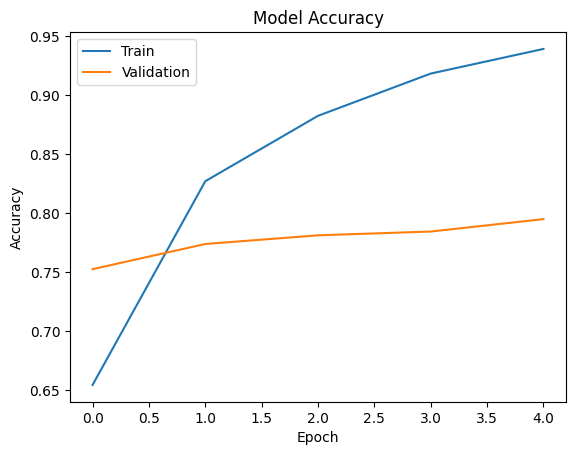

In [26]:
from matplotlib import pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

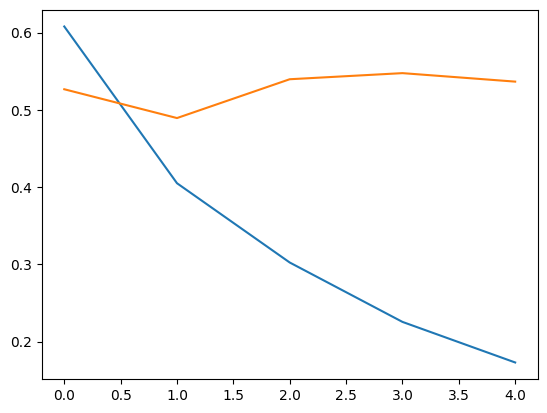

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [28]:
#DEFINE THE RNN MODEL
model1 = Sequential([
    Embedding(10000,32,input_length=100),  # embedding layer to convert words into vectors
    SimpleRNN(5,return_sequences=True),    # another rnn layer of 5 units
    SimpleRNN(5),    # simple RNN layer with 5 units
    Dense(1,activation='sigmoid')             # output layer for binary classification
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 100, 5)         │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 960,755 (3.66 MB)

 Trainable params: 320,251 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 640,504 (2.44 MB)

In [29]:
model1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [30]:
history =model1.fit(X_train,y_train,epochs=5,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.5461 - loss: 0.6825 - val_accuracy: 0.7688 - val_loss: 0.5134
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.7301 - loss: 0.5425 - val_accuracy: 0.7656 - val_loss: 0.5141
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.8641 - loss: 0.3375 - val_accuracy: 0.7828 - val_loss: 0.5023
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9222 - loss: 0.2229 - val_accuracy: 0.7779 - val_loss: 0.5428
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9435 - loss: 0.1615 - val_accuracy: 0.7748 - val_loss: 0.6052


In [34]:
#DEFINE THE RNN MODEL
model2 = Sequential([
    Embedding(10000,32,input_length=100),  # embedding layer to convert words into vectors
    GRU(5,return_sequences=True),    # another rnn layer of 5 units
    GRU(5),    # simple RNN layer with 5 units
    Dense(1,activation='sigmoid')             # output layer for binary classification
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 100, 5)         │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 960,755 (3.66 MB)

 Trainable params: 320,251 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 640,504 (2.44 MB)